full

In [1]:
import os, random, json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             classification_report, precision_recall_curve, roc_curve,
                             f1_score, recall_score)
from scipy.stats import wilcoxon


In [2]:
# Config & reproducibility
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/project1/dataset.csv"   # <<-- replace with your path
OUT_DIR = "/content/drive/MyDrive/project1/gwo_models_results_full"
if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)

TARGET_COL = "stroke"
ID_COL = "id"  # if present drop it

Mounted at /content/drive


In [4]:
# Load dataset
# -------------------------
df = pd.read_csv(DATA_PATH)
print("Loaded dataset shape:", df.shape)
display(df.head())
if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])
df.columns = [c.strip() for c in df.columns]

print("Loaded dataset shape:", df.shape)
display(df.head())

Loaded dataset shape: (43400, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


Loaded dataset shape: (43400, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [5]:
# Basic encoding for known categories (adapt if your values differ)
df['gender'] = df['gender'].replace({'Male':1, 'Female':0, 'Other':0})
df['ever_married'] = df['ever_married'].replace({'Yes':1, 'No':0})
df['Residence_type'] = df['Residence_type'].replace({'Urban':1, 'Rural':0})


/tmp/ipython-input-2158441134.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male':1, 'Female':0, 'Other':0})
/tmp/ipython-input-2158441134.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ever_married'] = df['ever_married'].replace({'Yes':1, 'No':0})
/tmp/ipython-input-2158441134.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to t

In [6]:
# One-hot for work_type & smoking_status (drop_first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['work_type','smoking_status'], drop_first=True)


In [7]:
# Features & target
# -------------------------
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

In [8]:
# Preprocessing
# -------------------------
# 1) EM imputation (IterativeImputer)
imputer = IterativeImputer(random_state=SEED, max_iter=10)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [9]:
# 2) Min-Max scaling
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)


In [10]:
# 3) SMOTE-ENN
smoteenn = SMOTEENN(random_state=SEED)
X_res, y_res = smoteenn.fit_resample(X_scaled, y)
print("After SMOTE-ENN distribution:", pd.Series(y_res).value_counts().to_dict())


After SMOTE-ENN distribution: {1: 39638, 0: 36336}


In [11]:
# 4) Train/val/test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(X_res, y_res, test_size=0.3,
                                                    stratify=y_res, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,
                                                stratify=y_temp, random_state=SEED)
input_dim = X_train.shape[1]
print("Shapes -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)


Shapes -> train: (53181, 14) val: (11396, 14) test: (11397, 14)


In [12]:
# Convert to numpy arrays
X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train).ravel(); y_val = np.array(y_val).ravel(); y_test = np.array(y_test).ravel()


In [13]:
# Model Builders
# -------------------------
def build_ann(input_dim, params):
    units = int(params.get("units1", 128))
    dropout = float(params.get("dropout", 0.25))
    lr = float(params.get("lr", 1e-3))
    act = params.get("act", "relu")
    tf.keras.backend.clear_session()
    m = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(units, activation=act),
        layers.Dropout(dropout),
        layers.Dense(max(64, units//2), activation=act),
        layers.Dropout(dropout/2),
        layers.Dense(max(32, units//4), activation=act),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=optimizers.Adam(learning_rate=lr),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc")])
    return m

def build_dnn(input_dim, params):
    u1 = int(params.get("units1", 256))
    u2 = int(params.get("units2", 128))
    dropout = float(params.get("dropout", 0.3))
    lr = float(params.get("lr", 1e-3))
    act = params.get("act", "relu")
    tf.keras.backend.clear_session()
    m = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(u1, activation=act),
        layers.Dropout(dropout),
        layers.Dense(u2, activation=act),
        layers.Dropout(dropout/2),
        layers.Dense(max(64, u2//2), activation=act),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=optimizers.Adam(learning_rate=lr),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc")])
    return m

def build_cnn1d(input_dim, params):
    filters = int(params.get("filters", 64))
    units = int(params.get("units1", 128))
    dropout = float(params.get("dropout", 0.3))
    lr = float(params.get("lr", 1e-3))
    act = params.get("act", "relu")
    tf.keras.backend.clear_session()
    m = models.Sequential([
        layers.Input(shape=(input_dim,1)),
        layers.Conv1D(filters=filters, kernel_size=3, activation=act, padding="same"),
        layers.Conv1D(filters=min(filters*2,256), kernel_size=3, activation=act, padding="same"),
        layers.MaxPooling1D(2),
        layers.GlobalMaxPooling1D(),
        layers.Dense(units, activation=act),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=optimizers.Adam(learning_rate=lr),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc")])
    return m


In [14]:
# Baseline training (shorter) - for comparison
# -------------------------
es_base = callbacks.EarlyStopping(monitor="val_auc", patience=5, restore_best_weights=True, mode="max", verbose=1)

ann_base = build_ann(input_dim, {"units1":128, "dropout":0.25, "lr":1e-3, "act":"relu"})
ann_base.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=20, batch_size=64, callbacks=[es_base], verbose=1)

dnn_base = build_dnn(input_dim, {"units1":256, "units2":128, "dropout":0.3, "lr":1e-3, "act":"relu"})
dnn_base.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=20, batch_size=64, callbacks=[es_base], verbose=1)

X_train_cnn = X_train.reshape(-1, input_dim, 1); X_val_cnn = X_val.reshape(-1, input_dim, 1); X_test_cnn = X_test.reshape(-1, input_dim, 1)
cnn_base = build_cnn1d(input_dim, {"filters":32, "units1":128, "dropout":0.3, "lr":1e-3, "act":"relu"})
cnn_base.fit(X_train_cnn, y_train, validation_data=(X_val_cnn,y_val), epochs=20, batch_size=64, callbacks=[es_base], verbose=1)


Epoch 1/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc: 0.8590 - loss: 0.4641 - val_auc: 0.9244 - val_loss: 0.3391
Epoch 2/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.9156 - loss: 0.3541 - val_auc: 0.9328 - val_loss: 0.3204
Epoch 3/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9255 - loss: 0.3315 - val_auc: 0.9395 - val_loss: 0.3033
Epoch 4/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9309 - loss: 0.3171 - val_auc: 0.9442 - val_loss: 0.2885
Epoch 5/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9362 - loss: 0.3052 - val_auc: 0.9485 - val_loss: 0.2773
Epoch 6/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.9404 - loss: 0.2943 - val_auc: 0.9518 - val_loss: 0.2672
Epoch 7/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9422 - loss: 0.2882 - val_auc: 0.9552 - val_loss: 0.2583
Epoch 8/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9465 - loss: 0.2773 - val_auc: 0.9580 - val_loss: 0.2459
Epoch 9/20
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - au

In [15]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, recall_score, classification_report
)
import numpy as np

def eval_model(model, X, y, model_name="Model", is_cnn=False):
    # Reshape for CNN if needed
    if is_cnn:
        X = X.reshape(-1, X.shape[1], 1)

    # Predict probabilities and classes
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    # Compute metrics
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    acc = accuracy_score(y, y_pred)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auc = roc_auc_score(y, y_prob)
    f1 = f1_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # ✅ Print detailed report before returning
    print(f"\n=== {model_name} Evaluation ===")
    print(f"AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    print(f"Sensitivity: {sens:.4f}, Specificity: {spec:.4f}")
    print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}")
    print(f"FPR: {fpr:.4f}, FNR: {fnr:.4f}")
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print("\nClassification Report:\n", classification_report(y, y_pred, digits=4))

    # Return all metrics in a dictionary
    return {
        'Accuracy': acc, 'AUC': auc, 'Sensitivity': sens, 'Specificity': spec,
        'Precision': prec, 'Recall': rec, 'F1': f1,
        'FPR': fpr, 'FNR': fnr, 'y_prob': y_prob, 'y_pred': y_pred
    }

# Example usage
ann_base_res = eval_model(ann_base, X_test, y_test, model_name="ANN Baseline")
dnn_base_res = eval_model(dnn_base, X_test, y_test, model_name="DNN Baseline")
cnn_base_res = eval_model(cnn_base, X_test, y_test, model_name="CNN Baseline", is_cnn=True)

print("\n=== Baseline Summary (AUC) ===")
print(f"ANN: {ann_base_res['AUC']:.3f}, DNN: {dnn_base_res['AUC']:.3f}, CNN: {cnn_base_res['AUC']:.3f}")


357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== ANN Baseline Evaluation ===
AUC: 0.9782, Accuracy: 0.9345
Sensitivity: 0.9834, Specificity: 0.8813
Precision: 0.9004, Recall: 0.9834, F1-Score: 0.9400
FPR: 0.1187, FNR: 0.0166
Confusion Matrix: TN=4804, FP=647, FN=99, TP=5847

Classification Report:
               precision    recall  f1-score   support

           0     0.9798    0.8813    0.9280      5451
           1     0.9004    0.9834    0.9400      5946

    accuracy                         0.9345     11397
   macro avg     0.9401    0.9323    0.9340     11397
weighted avg     0.9384    0.9345    0.9343     11397

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== DNN Baseline Evaluation ===
AUC: 0.9868, Accuracy: 0.9517
Sensitivity: 0.9914, Specificity: 0.9085
Precision: 0.9220, Recall: 0.9914, F1-Score: 0.9554
FPR: 0.0915, FNR: 0.0086
Confusion Matrix: TN=4952, FP=499, FN=51, TP=5895

Classification Report:
               precision    recall  f1-score   support

           0     0.9898 

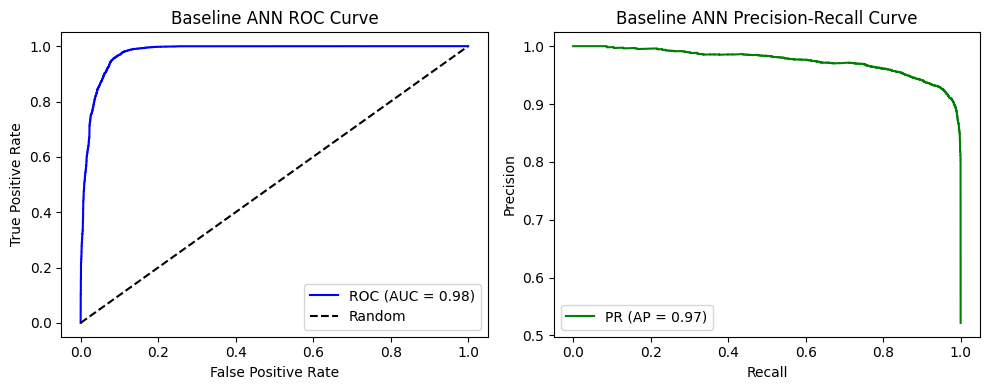

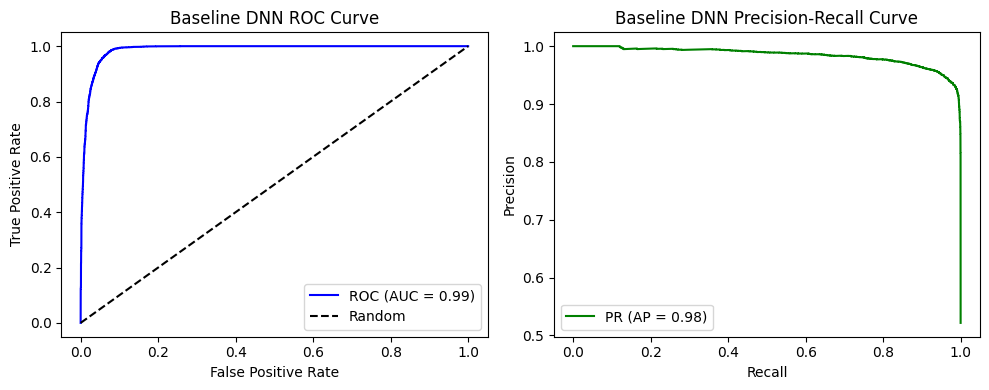

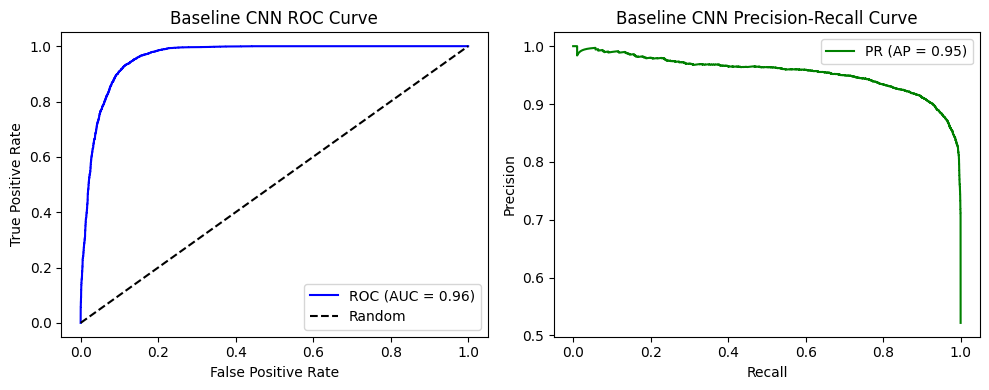

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_individual_model_curves(y_test, y_prob, model_name, title_prefix="Baseline"):
    plt.figure(figsize=(10,4))

    # --- ROC Curve ---
    plt.subplot(1,2,1)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='blue', label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title_prefix} {model_name} ROC Curve')
    plt.legend()

    # --- Precision-Recall Curve ---
    plt.subplot(1,2,2)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, color='green', label=f'PR (AP = {ap_score:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} {model_name} Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Example usage
plot_individual_model_curves(y_test, ann_base_res['y_prob'], "ANN")
plot_individual_model_curves(y_test, dnn_base_res['y_prob'], "DNN")
plot_individual_model_curves(y_test, cnn_base_res['y_prob'], "CNN")


In [17]:
# GWO Implementation (with weighted objective)
# -------------------------
def decode_act(code): return {0:"relu",1:"tanh",2:"elu"}[int(round(code)) % 3]

# Fitness wrappers for each model type
from sklearn.model_selection import train_test_split
X_gwo_tr, X_gwo_val, y_gwo_tr, y_gwo_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED)

def make_fitness(model_type):
    def fitness_fn(arr):
        # arr is a numpy vector with decoded values depending on model_type keys below
        params = {}
        if model_type == "ann":
            params = {"units1":int(arr[0]), "dropout":float(arr[1]), "lr":float(arr[2]), "act":decode_act(arr[3])}
            m = build_ann(input_dim, params)
            m.fit(X_gwo_tr, y_gwo_tr, validation_data=(X_gwo_val, y_gwo_val), epochs=8, batch_size=128, verbose=0)
            y_prob = m.predict(X_gwo_val).ravel()
            y_pred = (y_prob >= 0.5).astype(int)
            val_auc = roc_auc_score(y_gwo_val, y_prob)
            val_acc = (y_pred.flatten() == y_gwo_val).mean()
        elif model_type == "dnn":
            params = {"units1":int(arr[0]), "units2":int(arr[1]), "dropout":float(arr[2]), "lr":float(arr[3]), "act":decode_act(arr[4])}
            m = build_dnn(input_dim, params)
            m.fit(X_gwo_tr, y_gwo_tr, validation_data=(X_gwo_val, y_gwo_val), epochs=8, batch_size=128, verbose=0)
            y_prob = m.predict(X_gwo_val).ravel()
            y_pred = (y_prob >= 0.5).astype(int)
            val_auc = roc_auc_score(y_gwo_val, y_prob)
            val_acc = (y_pred.flatten() == y_gwo_val).mean()
        elif model_type == "cnn":
            params = {"filters":int(arr[0]), "units1":int(arr[1]), "dropout":float(arr[2]), "lr":float(arr[3]), "act":decode_act(arr[4])}
            m = build_cnn1d(input_dim, params)
            Xtr_c = X_gwo_tr.reshape(-1,input_dim,1); Xval_c = X_gwo_val.reshape(-1,input_dim,1)
            m.fit(Xtr_c, y_gwo_tr, validation_data=(Xval_c, y_gwo_val), epochs=8, batch_size=128, verbose=0)
            y_prob = m.predict(Xval_c).ravel()
            y_pred = (y_prob >= 0.5).astype(int)
            val_auc = roc_auc_score(y_gwo_val, y_prob)
            val_acc = (y_pred.flatten() == y_gwo_val).mean()
        else:
            return 1.0
        # Weighted combined score (prioritize AUC)
        score = 0.6 * val_auc + 0.4 * val_acc
        # GWO minimizes fitness -> return 1 - score
        return float(1.0 - score)
    return fitness_fn

In [18]:
# GWO search space definitions (as arrays)
ann_bounds = [("units1",32,256,True), ("dropout",0.0,0.5,False), ("lr",1e-5,5e-3,False), ("act_code",0,2,True)]
dnn_bounds = [("units1",64,512,True), ("units2",32,256,True), ("dropout",0.0,0.5,False), ("lr",1e-5,5e-3,False), ("act_code",0,2,True)]
cnn_bounds = [("filters",8,128,True), ("units1",32,256,True), ("dropout",0.0,0.5,False), ("lr",1e-5,5e-3,False), ("act_code",0,2,True)]

# Generic GWO implementation using arrays
def gwo_optimize_generic(bounds, fitness_fn, pop_size=20, max_iter=30, seed=SEED):
    random.seed(seed); np.random.seed(seed)
    dim = len(bounds)
    # initialize population
    pop = []
    for _ in range(pop_size):
        x = np.zeros(dim, dtype=float)
        for i,(name,low,high,is_int) in enumerate(bounds):
            if is_int:
                x[i] = float(random.randint(int(low), int(high)))
            else:
                x[i] = random.uniform(low, high)
        pop.append(x)
    # evaluate
    scores = np.array([fitness_fn(ind) for ind in pop], dtype=float)
    sorted_idx = np.argsort(scores)  # low is better because fitness = 1 - score
    alpha, beta, delta = pop[sorted_idx[0]].copy(), pop[sorted_idx[1]].copy(), pop[sorted_idx[2]].copy()
    alpha_score = scores[sorted_idx[0]]
    for t in range(max_iter):
        a = 2 * (1 - t / float(max_iter))
        for i in range(pop_size):
            X = pop[i].copy()
            r1 = np.random.rand(dim); r2 = np.random.rand(dim)
            A1 = 2 * a * r1 - a; C1 = 2 * r2
            D_alpha = np.abs(C1 * alpha - X); X1 = alpha - A1 * D_alpha
            r1 = np.random.rand(dim); r2 = np.random.rand(dim)
            A2 = 2 * a * r1 - a; C2 = 2 * r2
            D_beta = np.abs(C2 * beta - X); X2 = beta - A2 * D_beta
            r1 = np.random.rand(dim); r2 = np.random.rand(dim)
            A3 = 2 * a * r1 - a; C3 = 2 * r2
            D_delta = np.abs(C3 * delta - X); X3 = delta - A3 * D_delta
            newX = (X1 + X2 + X3) / 3.0
            # clip & cast ints
            for j,(name,low,high,is_int) in enumerate(bounds):
                newX[j] = np.clip(newX[j], low, high)
                if is_int:
                    newX[j] = int(round(newX[j]))
            pop[i] = newX
        scores = np.array([fitness_fn(ind) for ind in pop], dtype=float)
        sorted_idx = np.argsort(scores)
        alpha, beta, delta = pop[sorted_idx[0]].copy(), pop[sorted_idx[1]].copy(), pop[sorted_idx[2]].copy()
        alpha_score = scores[sorted_idx[0]]
        print(f"[GWO] iter {t+1}/{max_iter} best_fitness = {alpha_score:.6f} (best_score = {1-alpha_score:.6f})")
    # decode alpha into dict
    best_arr = alpha
    best = {}
    for j,(name,low,high,is_int) in enumerate(bounds):
        val = int(round(best_arr[j])) if is_int else float(best_arr[j])
        best[name] = val
    return best, float(1 - alpha_score)


In [19]:
# Run GWO for each model type
print("\n=== Running GWO for ANN (this may take a while) ===")
ann_fitness = make_fitness("ann")
ann_best, ann_best_score = gwo_optimize_generic(ann_bounds, ann_fitness, pop_size=10, max_iter=10)
ann_best['act'] = decode_act(ann_best['act_code']) if 'act_code' in ann_best else 'relu'
print("ANN best:", ann_best, "val score:", ann_best_score)


=== Running GWO for ANN (this may take a while) ===
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[GWO] iter 1/10 best_fitness = 0.047293 (best_score = 0.952707)
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━

In [20]:
print("\n=== Running GWO for DNN ===")
dnn_fitness = make_fitness("dnn")
dnn_best, dnn_best_score = gwo_optimize_generic(dnn_bounds, dnn_fitness, pop_size=10, max_iter=10)
dnn_best['act'] = decode_act(dnn_best['act_code']) if 'act_code' in dnn_best else 'relu'
print("DNN best:", dnn_best, "val score:", dnn_best_score)



=== Running GWO for DNN ===
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[GWO] iter 1/10 best_fitness = 0.044629 (best_score = 0.955371)
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
333/3

In [21]:
print("\n=== Running GWO for CNN ===")
cnn_fitness = make_fitness("cnn")
cnn_best, cnn_best_score = gwo_optimize_generic(cnn_bounds, cnn_fitness, pop_size=10, max_iter=10)
cnn_best['act'] = decode_act(cnn_best['act_code']) if 'act_code' in cnn_best else 'relu'
print("CNN best:", cnn_best, "val score:", cnn_best_score)


=== Running GWO for CNN ===
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[GWO] iter 1/10 best_fitness = 0.084755 (best_score = 0.915245)
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
333/3

In [22]:
# Retrain Final Optimized Models (Full epochs)
# -------------------------
es_final = callbacks.EarlyStopping(monitor="val_auc", patience=8, restore_best_weights=True, mode="max", verbose=1)

# ANN
ann_final = build_ann(input_dim, ann_best)
ann_final.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=40, batch_size=64, callbacks=[es_final], verbose=1)


Epoch 1/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - auc: 0.8948 - loss: 0.3921 - val_auc: 0.9335 - val_loss: 0.3126
Epoch 2/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.9316 - loss: 0.3143 - val_auc: 0.9447 - val_loss: 0.2835
Epoch 3/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.9437 - loss: 0.2837 - val_auc: 0.9540 - val_loss: 0.2578
Epoch 4/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.9540 - loss: 0.2553 - val_auc: 0.9602 - val_loss: 0.2371
Epoch 5/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - auc: 0.9620 - loss: 0.2316 - val_auc: 0.9685 - val_loss: 0.2098
Epoch 6/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - auc: 0.9694 - loss: 0.2058 - val_auc: 0.9705 - val_loss: 0.2034
Epoch 7/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.9760 - loss: 0.1812 - val_auc: 0.9806 - val_loss: 0.1618
Epoch 8/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.9803 - loss: 0.1612 - val_auc: 0.9844 - val_loss: 0.1451
Epoch 9/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - au

In [23]:
# DNN
dnn_final = build_dnn(input_dim, dnn_best)
dnn_final.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=40, batch_size=64, callbacks=[es_final], verbose=1)


Epoch 1/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - auc: 0.8944 - loss: 0.3931 - val_auc: 0.9333 - val_loss: 0.3111
Epoch 2/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - auc: 0.9282 - loss: 0.3222 - val_auc: 0.9426 - val_loss: 0.2914
Epoch 3/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.9398 - loss: 0.2945 - val_auc: 0.9516 - val_loss: 0.2688
Epoch 4/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - auc: 0.9495 - loss: 0.2702 - val_auc: 0.9604 - val_loss: 0.2393
Epoch 5/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - auc: 0.9568 - loss: 0.2474 - val_auc: 0.9633 - val_loss: 0.2317
Epoch 6/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.9633 - loss: 0.2271 - val_auc: 0.9724 - val_loss: 0.1914
Epoch 7/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - auc: 0.9694 - loss: 0.2059 - val_auc: 0.9788 - val_loss: 0.1747
Epoch 8/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - auc: 0.9737 - loss: 0.1897 - val_auc: 0.9833 - val_loss: 0.1510
Epoch 9/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - au

In [24]:
# CNN
cnn_final = build_cnn1d(input_dim, cnn_best)
cnn_final.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val),
              epochs=40, batch_size=64, callbacks=[es_final], verbose=1)


Epoch 1/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - auc: 0.8607 - loss: 0.4457 - val_auc: 0.9096 - val_loss: 0.3692
Epoch 2/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - auc: 0.9083 - loss: 0.3666 - val_auc: 0.9211 - val_loss: 0.3540
Epoch 3/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - auc: 0.9165 - loss: 0.3506 - val_auc: 0.9295 - val_loss: 0.3322
Epoch 4/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - auc: 0.9269 - loss: 0.3306 - val_auc: 0.9404 - val_loss: 0.3060
Epoch 5/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - auc: 0.9357 - loss: 0.3099 - val_auc: 0.9474 - val_loss: 0.2904
Epoch 6/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - auc: 0.9435 - loss: 0.2903 - val_auc: 0.9531 - val_loss: 0.2644
Epoch 7/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - auc: 0.9499 - loss: 0.2726 - val_auc: 0.9569 - val_loss: 0.2524
Epoch 8/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - auc: 0.9542 - loss: 0.2591 - val_auc: 0.9603 - val_loss: 0.2497
Epoch 9/40
831/831 ━━━━━━━━━━━━━━━━━━━━ 

In [25]:
# Final Evaluation
# -------------------------
ann_metrics = eval_model(ann_final, X_test, y_test)
dnn_metrics = eval_model(dnn_final, X_test, y_test)
cnn_metrics = eval_model(cnn_final, X_test, y_test, is_cnn=True)

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Model Evaluation ===
AUC: 0.9959, Accuracy: 0.9810
Sensitivity: 0.9929, Specificity: 0.9681
Precision: 0.9714, Recall: 0.9929, F1-Score: 0.9820
FPR: 0.0319, FNR: 0.0071
Confusion Matrix: TN=5277, FP=174, FN=42, TP=5904

Classification Report:
               precision    recall  f1-score   support

           0     0.9921    0.9681    0.9799      5451
           1     0.9714    0.9929    0.9820      5946

    accuracy                         0.9810     11397
   macro avg     0.9817    0.9805    0.9810     11397
weighted avg     0.9813    0.9810    0.9810     11397

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Model Evaluation ===
AUC: 0.9959, Accuracy: 0.9770
Sensitivity: 0.9928, Specificity: 0.9598
Precision: 0.9642, Recall: 0.9928, F1-Score: 0.9783
FPR: 0.0402, FNR: 0.0072
Confusion Matrix: TN=5232, FP=219, FN=43, TP=5903

Classification Report:
               precision    recall  f1-score   support

           0     0.9918    0.9598    0

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- ANN (GWO) ---
Accuracy: 0.9810 | ROC-AUC: 0.9959
Sensitivity (Recall for pos): 0.9929 | Specificity: 0.9681
FPR: 0.0319 | FNR: 0.0071
Precision: 0.9714 | Recall: 0.9929 | F1-score: 0.9820

Classification Report:
               precision    recall  f1-score   support

           0     0.9921    0.9681    0.9799      5451
           1     0.9714    0.9929    0.9820      5946

    accuracy                         0.9810     11397
   macro avg     0.9817    0.9805    0.9810     11397
weighted avg     0.9813    0.9810    0.9810     11397



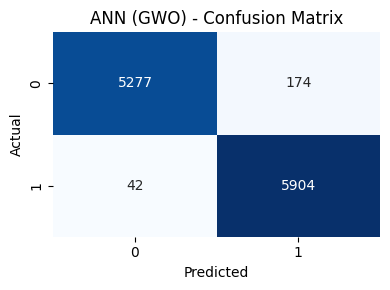

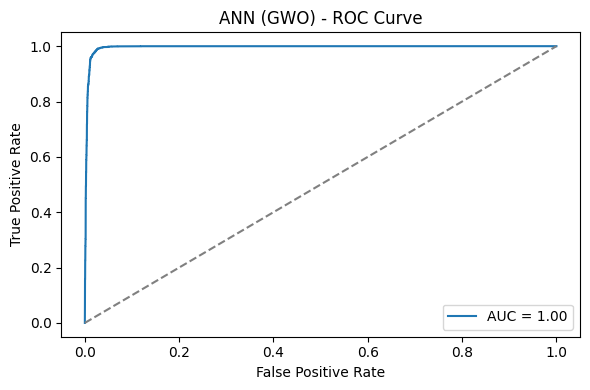

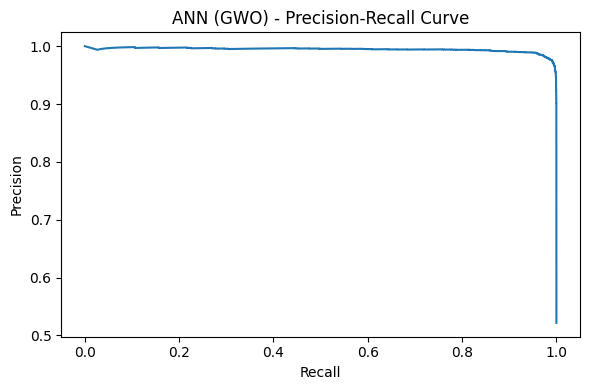

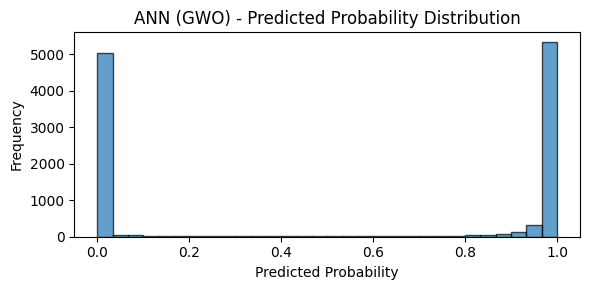

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- DNN (GWO) ---
Accuracy: 0.9770 | ROC-AUC: 0.9959
Sensitivity (Recall for pos): 0.9928 | Specificity: 0.9598
FPR: 0.0402 | FNR: 0.0072
Precision: 0.9642 | Recall: 0.9928 | F1-score: 0.9783

Classification Report:
               precision    recall  f1-score   support

           0     0.9918    0.9598    0.9756      5451
           1     0.9642    0.9928    0.9783      5946

    accuracy                         0.9770     11397
   macro avg     0.9780    0.9763    0.9769     11397
weighted avg     0.9774    0.9770    0.9770     11397



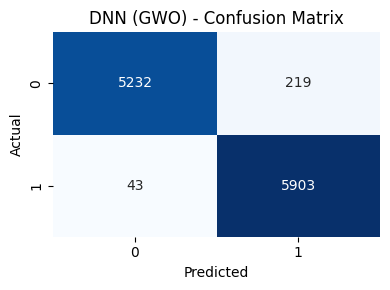

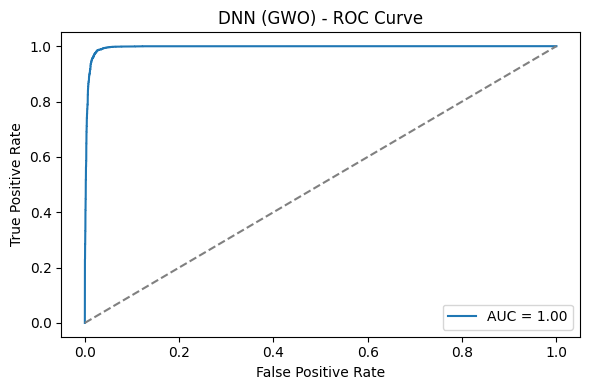

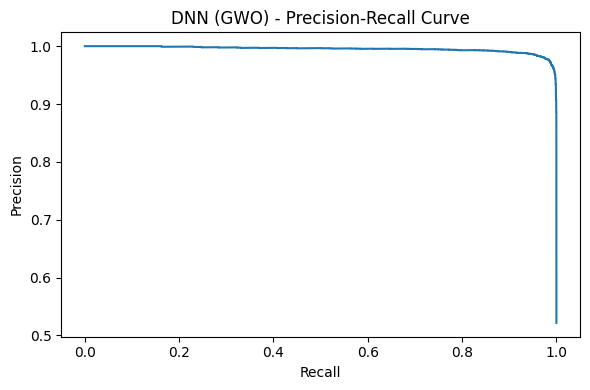

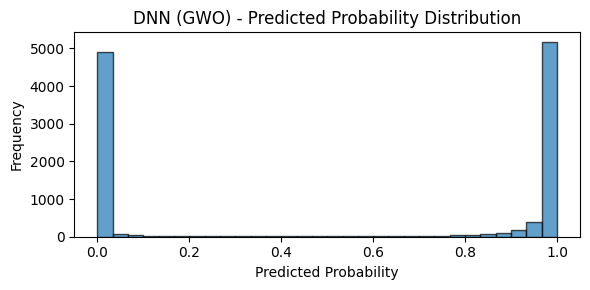

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- CNN (GWO) ---
Accuracy: 0.9488 | ROC-AUC: 0.9840
Sensitivity (Recall for pos): 0.9884 | Specificity: 0.9057
FPR: 0.0943 | FNR: 0.0116
Precision: 0.9196 | Recall: 0.9884 | F1-score: 0.9527

Classification Report:
               precision    recall  f1-score   support

           0     0.9862    0.9057    0.9442      5451
           1     0.9196    0.9884    0.9527      5946

    accuracy                         0.9488     11397
   macro avg     0.9529    0.9471    0.9485     11397
weighted avg     0.9514    0.9488    0.9487     11397



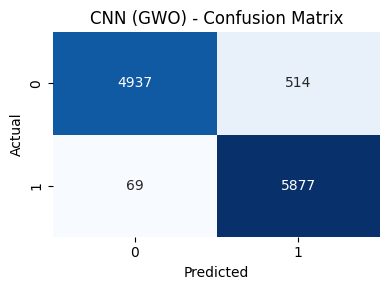

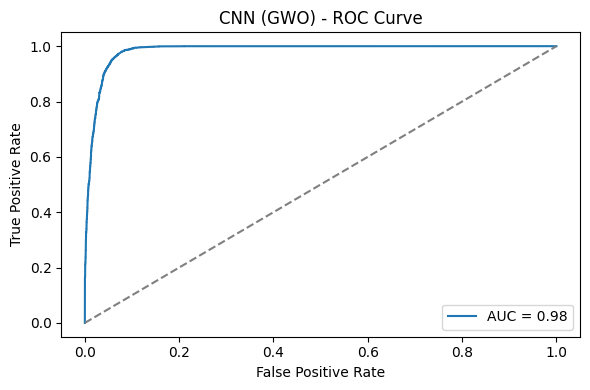

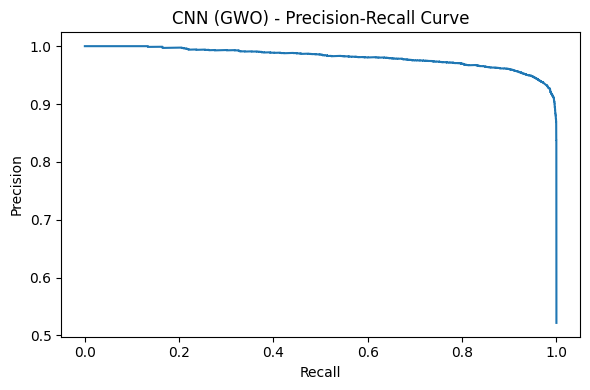

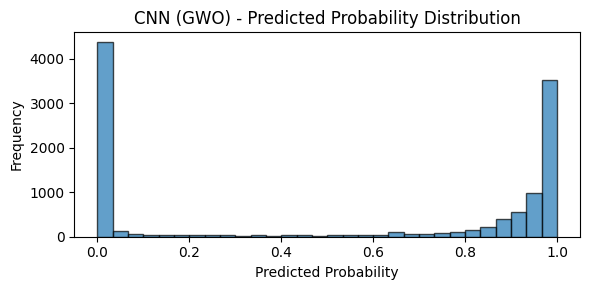

In [26]:
# === Evaluation + plotting helper (corrected & robust) ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, classification_report,
    f1_score, precision_score, recall_score
)

def evaluate_and_plot(y_true, y_prob=None, y_pred=None, model=None, X=None, is_cnn=False, model_name="Model"):
    """
    Evaluate model predictions and plot metrics.
    - Either provide (y_prob and y_pred) directly OR provide (model and X) to compute them.
    - If is_cnn=True and you pass model+X, X will be reshaped to (n, input_dim, 1) before predict.
    Returns: dict with Accuracy, AUC, Sensitivity, Specificity, FPR, FNR, F1, Precision, Recall
    """
    # --- compute probabilities & preds if model+X provided ---
    if (y_prob is None or y_pred is None) and (model is not None and X is not None):
        # reshape for cnn
        X_in = X
        if is_cnn:
            X_in = X.reshape(-1, X.shape[1], 1)
        y_prob = model.predict(X_in).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    elif y_prob is None or y_pred is None:
        raise ValueError("Either pass both y_prob and y_pred, or pass model and X to compute them.")

    # ensure arrays are 1D numpy
    y_true = np.array(y_true).ravel()
    y_prob = np.array(y_prob).ravel()
    y_pred = np.array(y_pred).ravel()

    # --- handle edge cases ---
    if len(y_true) != len(y_prob) or len(y_true) != len(y_pred):
        raise ValueError("Length mismatch between y_true, y_prob and y_pred.")

    # --- metrics ---
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # --- print summary ---
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")
    print(f"Sensitivity (Recall for pos): {sensitivity:.4f} | Specificity: {specificity:.4f}")
    print(f"FPR: {fpr:.4f} | FNR: {fnr:.4f}")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

    # --- confusion matrix plot ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # --- ROC curve ---
    try:
        fpr_vals, tpr_vals, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(fpr_vals, tpr_vals, label=f"AUC = {auc:.2f}")
        plt.plot([0,1], [0,1], '--', color='gray')
        plt.title(f"{model_name} - ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("ROC plot skipped (error):", e)

    # --- Precision-Recall curve ---
    try:
        prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(rec_vals, prec_vals)
        plt.title(f"{model_name} - Precision-Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Precision-Recall plot skipped (error):", e)

    # --- probability histogram ---
    plt.figure(figsize=(6,3))
    plt.hist(y_prob, bins=30, edgecolor='k', alpha=0.7)
    plt.title(f"{model_name} - Predicted Probability Distribution")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # --- return metrics dict ---
    return {
        "Accuracy": acc,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

# ---------------------------
# Example usage (after training)
# ---------------------------
# For ANN:
y_prob_ann = ann_final.predict(X_test).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)
ann_metrics = evaluate_and_plot(y_test, y_prob=y_prob_ann, y_pred=y_pred_ann, model_name="ANN (GWO)")

# For DNN:
y_prob_dnn = dnn_final.predict(X_test).ravel()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)
dnn_metrics = evaluate_and_plot(y_test, y_prob=y_prob_dnn, y_pred=y_pred_dnn, model_name="DNN (GWO)")

# For CNN (ensure X_test_cnn exists as reshaped n x input_dim x 1)
y_prob_cnn = cnn_final.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
cnn_metrics = evaluate_and_plot(y_test, y_prob=y_prob_cnn, y_pred=y_pred_cnn, is_cnn=False, model_name="CNN (GWO)")


In [33]:
# Comparison Table
# -------------------------
df_comp = pd.DataFrame([
    ['ANN', 'Baseline', ann_base_res['Accuracy'], ann_base_res['AUC'], ann_base_res['Sensitivity'], ann_base_res['Specificity']],
    ['ANN', 'Optimized', ann_metrics['Accuracy'], ann_metrics['AUC'], ann_metrics['Sensitivity'], ann_metrics['Specificity']],
    ['DNN', 'Baseline', dnn_base_res['Accuracy'], dnn_base_res['AUC'], dnn_base_res['Sensitivity'], dnn_base_res['Specificity']],
    ['DNN', 'Optimized', dnn_metrics['Accuracy'], dnn_metrics['AUC'], dnn_metrics['Sensitivity'], dnn_metrics['Specificity']],
    ['CNN', 'Baseline', cnn_base_res['Accuracy'], cnn_base_res['AUC'], cnn_base_res['Sensitivity'], cnn_base_res['Specificity']],
    ['CNN', 'Optimized', cnn_metrics['Accuracy'], cnn_metrics['AUC'], cnn_metrics['Sensitivity'], cnn_metrics['Specificity']]
], columns=['Model','Type','Accuracy','AUC','Sensitivity','Specificity'])

print("\n=== Final Comparison Table ===")
print(df_comp)

import os

OUT_DIR = "/content/drive/MyDrive/project1/gwo_models_results_full"
os.makedirs(OUT_DIR, exist_ok=True)

df_comp.to_csv(os.path.join(OUT_DIR, "comparison_table.csv"), index=False)



=== Final Comparison Table ===
  Model       Type  Accuracy       AUC  Sensitivity  Specificity
0   ANN   Baseline  0.934544  0.978208     0.983350     0.881306
1   ANN  Optimized  0.981048  0.995947     0.992936     0.968079
2   DNN   Baseline  0.951742  0.986808     0.991423     0.908457
3   DNN  Optimized  0.977011  0.995863     0.992768     0.959824
4   CNN   Baseline  0.908836  0.962225     0.930037     0.885709
5   CNN  Optimized  0.948846  0.983996     0.988396     0.905705


In [34]:
# ======================================================
# Improvement Analysis: Baseline vs Optimized (AUC gain)
# ======================================================
print("\n=== Improvement Analysis ===")

imp_rows = []
for model in ['ANN', 'DNN', 'CNN']:
    try:
        base_auc = df_comp.loc[
            (df_comp['Model'] == model) & (df_comp['Type'] == 'Baseline'),
            'AUC'
        ].values[0]
        opt_auc = df_comp.loc[
            (df_comp['Model'] == model) & (df_comp['Type'] == 'Optimized'),
            'AUC'
        ].values[0]
        imp = (opt_auc - base_auc) / base_auc * 100
        imp_rows.append([model, round(base_auc, 4), round(opt_auc, 4), f"{imp:+.2f}%"])
    except Exception:
        pass

if imp_rows:
    df_imp = pd.DataFrame(imp_rows, columns=['Model', 'Baseline AUC', 'Optimized AUC', '% Improvement'])
    print("\nModel-wise AUC Improvement:")
    display(df_imp)
else:
    print("No improvement data available — ensure df_comp contains both Baseline and Optimized metrics.")



=== Improvement Analysis ===

Model-wise AUC Improvement:


,Model,Baseline AUC,Optimized AUC,% Improvement
0,ANN,0.9782,0.9959,+1.81%
1,DNN,0.9868,0.9959,+0.92%
2,CNN,0.9622,0.9840,+2.26%


In [35]:
# Save Final Models
# -------------------------
ann_final.save(os.path.join(OUT_DIR, "ann_gwo_final.h5"))
dnn_final.save(os.path.join(OUT_DIR, "dnn_gwo_final.h5"))
cnn_final.save(os.path.join(OUT_DIR, "cnn_gwo_final.h5"))
print("Saved all optimized models to:", OUT_DIR)

Saved all optimized models to: /content/drive/MyDrive/project1/gwo_models_results_full


/tmp/ipython-input-2299251945.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=melted, x='Model', y='Score', hue='Type', palette='Set2', ci=None)


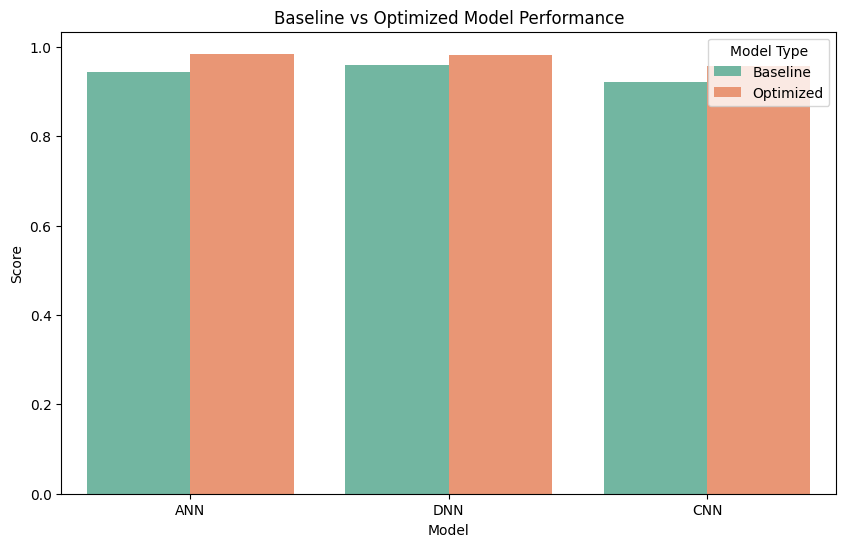

In [37]:
# ======================================================
# Bar Chart Comparison: Baseline vs Optimized
# ======================================================
if 'df_comp' in locals() and not df_comp.empty:
    metrics_to_plot = ['Accuracy', 'AUC', 'Sensitivity', 'Specificity']
    melted = df_comp.melt(id_vars=['Model', 'Type'], value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

    plt.figure(figsize=(10, 6))
    sns.barplot(data=melted, x='Model', y='Score', hue='Type', palette='Set2', ci=None)
    plt.title('Baseline vs Optimized Model Performance')
    plt.ylabel('Score')
    plt.legend(title='Model Type')
    plt.show()
else:
    print("⚠️ df_comp not available or empty — run evaluation section first.")


In [38]:
# === Wilcoxon test on prediction probabilities (baseline vs optimized) ===
print("\\n=== Wilcoxon test (baseline vs optimized probabilities) ===")
try:
    stat, p = wilcoxon(ann_base_res['y_prob'], y_prob_ann)
    print(f"ANN: stat={stat:.4f}, p={p:.4e}")
except Exception as e:
    print("ANN Wilcoxon failed:", e)
try:
    stat, p = wilcoxon(dnn_base_res['y_prob'], y_prob_dnn)
    print(f"DNN: stat={stat:.4f}, p={p:.4e}")
except Exception as e:
    print("DNN Wilcoxon failed:", e)
try:
    stat, p = wilcoxon(cnn_base_res['y_prob'], y_prob_cnn)
    print(f"CNN: stat={stat:.4f}, p={p:.4e}")
except Exception as e:
    print("CNN Wilcoxon failed:", e)


\n=== Wilcoxon test (baseline vs optimized probabilities) ===
ANN: stat=25567986.0000, p=4.2261e-86
DNN: stat=25037000.5000, p=1.4491e-97
CNN: stat=22218996.5000, p=1.9265e-187


In [42]:
# Binary Prediction Output (Example)
# -------------------------
print("\n=== Example: Binary Prediction Outputs ===")
y_pred_proba = cnn_final.predict(X_test_cnn)
y_pred = (y_pred_proba > 0.5).astype(int)
for i in range(10):
    print(f"Patient {i+1}: Probability = {y_pred_proba[i][0]:.3f}, Predicted = {y_pred[i][0]}")
print("\nLegend:\n1 → Stroke likely\n0 → No stroke likely")

print("\nPipeline complete ✅\nAll models, metrics, and figures saved in:", OUT_DIR)


=== Example: Binary Prediction Outputs ===
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Patient 1: Probability = 0.994, Predicted = 1
Patient 2: Probability = 0.000, Predicted = 0
Patient 3: Probability = 0.000, Predicted = 0
Patient 4: Probability = 0.196, Predicted = 0
Patient 5: Probability = 0.834, Predicted = 1
Patient 6: Probability = 0.996, Predicted = 1
Patient 7: Probability = 0.000, Predicted = 0
Patient 8: Probability = 0.000, Predicted = 0
Patient 9: Probability = 0.869, Predicted = 1
Patient 10: Probability = 0.998, Predicted = 1

Legend:
1 → Stroke likely
0 → No stroke likely

Pipeline complete ✅
All models, metrics, and figures saved in: /content/drive/MyDrive/project1/gwo_models_results_full



=== Model Comparison Data ===
  Model       Type  Accuracy       AUC  Sensitivity  Specificity
0   ANN   Baseline  0.934544  0.978208     0.983350     0.881306
1   ANN  Optimized  0.981048  0.995947     0.992936     0.968079
2   DNN   Baseline  0.951742  0.986808     0.991423     0.908457
3   DNN  Optimized  0.977011  0.995863     0.992768     0.959824
4   CNN   Baseline  0.908836  0.962225     0.930037     0.885709
5   CNN  Optimized  0.948846  0.983996     0.988396     0.905705


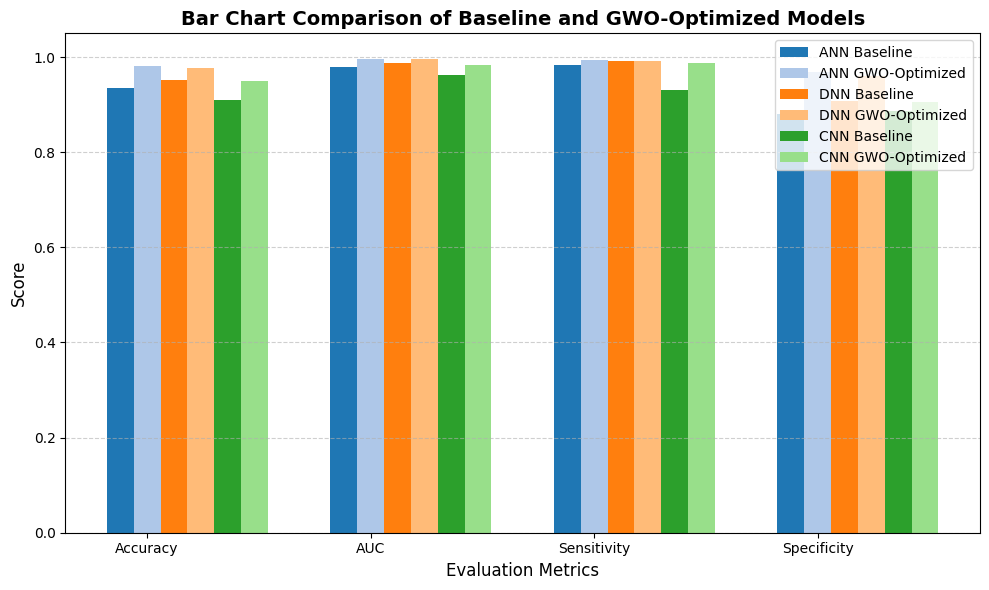

✅ Bar chart saved as 'bar_chart_comparison.png'


In [44]:
# ==========================================
# Bar Chart: Comparison of Baseline vs GWO-Optimized Models
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure df_comp exists (it should be created after your final evaluations)
# Columns expected: ['Model','Type','Accuracy','AUC','Sensitivity','Specificity']

# If df_comp not in memory, uncomment below line to reload:
# df_comp = pd.read_csv("/content/gwo_models_results_full/comparison_table.csv")

print("\n=== Model Comparison Data ===")
print(df_comp)

# Metrics to compare
metrics = ['Accuracy', 'AUC', 'Sensitivity', 'Specificity']
x = np.arange(len(metrics))
width = 0.12

# Figure setup
plt.figure(figsize=(10,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']        # baseline colors
opt_colors = ['#aec7e8', '#ffbb78', '#98df8a']    # optimized lighter shades

# Plot bars for each model (Baseline vs Optimized)
for i, model in enumerate(['ANN', 'DNN', 'CNN']):
    base_vals = df_comp.loc[(df_comp['Model'] == model) & (df_comp['Type'] == 'Baseline'), metrics].values[0]
    opt_vals  = df_comp.loc[(df_comp['Model'] == model) & (df_comp['Type'] == 'Optimized'), metrics].values[0]
    plt.bar(x + i*(width*2), base_vals, width, label=f'{model} Baseline', color=colors[i])
    plt.bar(x + i*(width*2) + width, opt_vals, width, label=f'{model} GWO-Optimized', color=opt_colors[i])

# Chart labels and title
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Bar Chart Comparison of Baseline and GWO-Optimized Models', fontsize=14, weight='bold')
plt.xticks(x + width, metrics)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save and show
plt.tight_layout()
plt.savefig("bar_chart_comparison.png", dpi=300)
plt.show()

print("✅ Bar chart saved as 'bar_chart_comparison.png'")
